# **MEDICAL  DATASET  CLEANING USING PYTHON**

# **INTRODUCTION**
This project focuses on cleaning and preprocessing a medical appointment dataset to improve data quality and reliablity . Using Python and libraries like Pandas , key steps such as handling missing values , removing  duplicates , standardizing text formats and correcting data types were performed . The cleaned dataset is prepared for further analysis to understand patient appointment behaviour , especially no-shows patterns .

# **OBJECTIVE**
To clean and preprocess the dataset by handling missing values , removing duplicates , standardizing text , fixing date formats , renaming columns and correcting data types to make it ready for analysis .

# **TOOLS & LIBRARIES**

*   Python
*   NumPy
*   Pandas

# **IMPORT & UPLOAD FILE**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving KaggleV2-May-2016.csv to KaggleV2-May-2016.csv


# **IMPORT LIBRARIES**

In [29]:
import pandas as ps
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Style
sns.set_style("whitegrid")

# **LOAD DATASET**

In [6]:
df = ps.read_csv("KaggleV2-May-2016.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# **UNDERSTAND THE DATA**

In [7]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

# **HANDLE MISSING VALUES**

In [8]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


# **REMOVE DUPLICATE ROWS**

In [9]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# **STANDARDIZE TEXT VALUES**

In [11]:
df['Gender'] = df['Gender'].str.upper()
df['Gender'].head()

,Gender
0,F
1,M
2,F
3,F
4,F


In [12]:
df['Gender']=df['Gender'].replace('F','FEMALE')
df['Gender']=df['Gender'].replace('M','MALE')
df['Gender'].head()

,Gender
0,FEMALE
1,MALE
2,FEMALE
3,FEMALE
4,FEMALE


# **CONVERT DATE FORMAT**

In [14]:
df['ScheduledDay'] = ps.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = ps.to_datetime(df['AppointmentDay'])
df[['ScheduledDay','AppointmentDay']].head()

,ScheduledDay,AppointmentDay
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00


In [15]:
df['ScheduledDay'] = df['ScheduledDay'].dt.strftime('%Y-%m-%d')
df['AppointmentDay'] = df['AppointmentDay'].dt.strftime('%Y-%m-%d')
df[['ScheduledDay','AppointmentDay']].head()

,ScheduledDay,AppointmentDay
0,2016-04-29,2016-04-29
1,2016-04-29,2016-04-29
2,2016-04-29,2016-04-29
3,2016-04-29,2016-04-29
4,2016-04-29,2016-04-29


# **RENAME COLUMNS HEADERS**

In [18]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['patientid', 'appointmentid', 'gender', 'scheduledday',
       'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no-show'],
      dtype='object')

# **FIX DATA TYPES**

In [19]:
df.dtypes

,0
patientid,float64
appointmentid,int64
gender,object
scheduledday,object
appointmentday,object
age,int64
neighbourhood,object
scholarship,int64
hipertension,int64
diabetes,int64


In [22]:
df['age'] = df['age'].astype(int)
df['patientid'] = df['patientid'].astype(int)
df['patientid'].head()

,patientid
0,29872499824296
1,558997776694438
2,4262962299951
3,867951213174
4,8841186448183


# **ADDITIONAL CLEANING**

In [24]:
df = df[df['age']>=0]
df['age'].head()

,age
0,62
1,56
2,62
3,8
4,56


In [25]:
df['no-show'] = df['no-show'].replace({'Yes': 1, 'No': 0})
df['no-show'].head()

/tmp/ipykernel_2223/2031328752.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['no-show'] = df['no-show'].replace({'Yes': 1, 'No': 0})


,no-show
0,0
1,0
2,0
3,0
4,0


# **SAVE CLEANED DATASET**

In [28]:
df.to_csv("cleaned_medical_data.csv",index=False)

# **DATA VISUALIZATION**

# **NO-SHOW DISTRIBUTION**

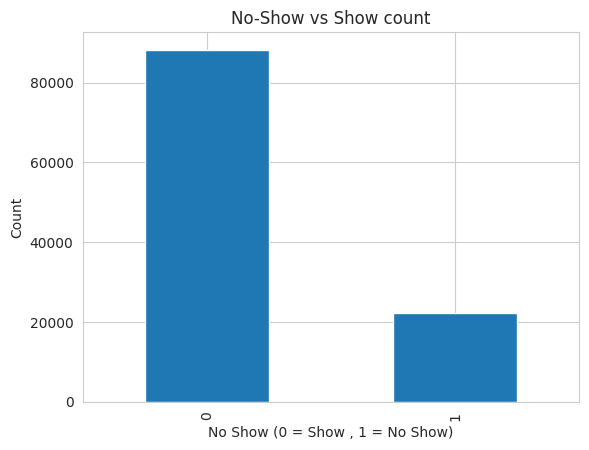

In [31]:
df['no-show'].value_counts().plot(kind='bar')
plt.title("No-Show vs Show count")
plt.xlabel("No Show (0 = Show , 1 = No Show)")
plt.ylabel("Count")
plt.show()

# **GENDER vs NO-SHOW**

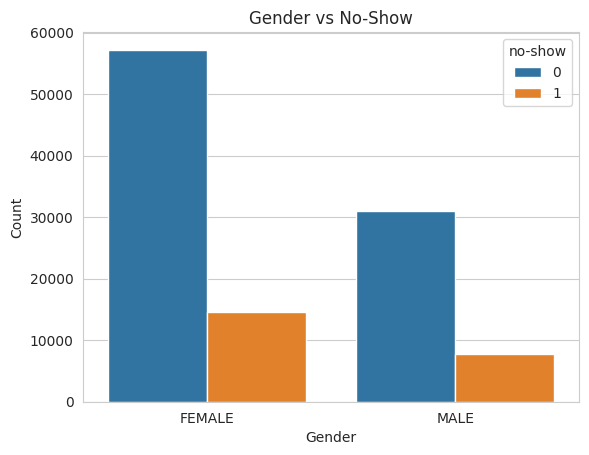

In [32]:
sns.countplot(x='gender', hue='no-show', data=df)
plt.title("Gender vs No-Show")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# **AGE DISTRIBUTION**

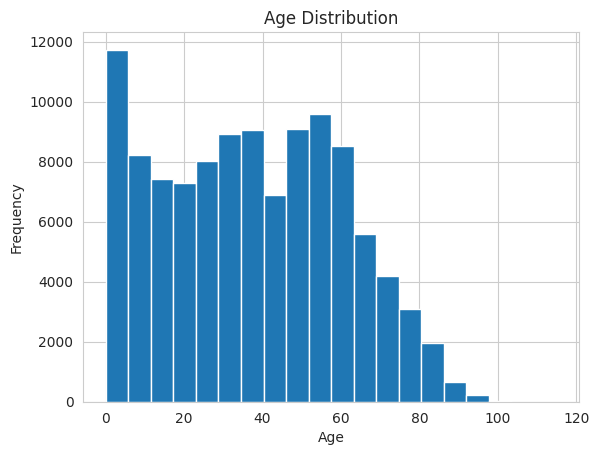

In [33]:
plt.hist(df['age'],bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# **WAITING TIME vs NO-SHOW**

In [39]:
df['scheduled_day'] = ps.to_datetime(df['scheduledday'])
df['appointment_day'] = ps.to_datetime(df['appointmentday'])
df['waiting_time'] = (df['appointment_day'] - df['scheduled_day']).dt.days
df['waiting_time'].head()
df['waiting_time'].describe()

,waiting_time
count,110526.000000
mean,10.183794
std,15.255034
min,-6.000000
25%,0.000000
50%,4.000000
75%,15.000000
max,179.000000


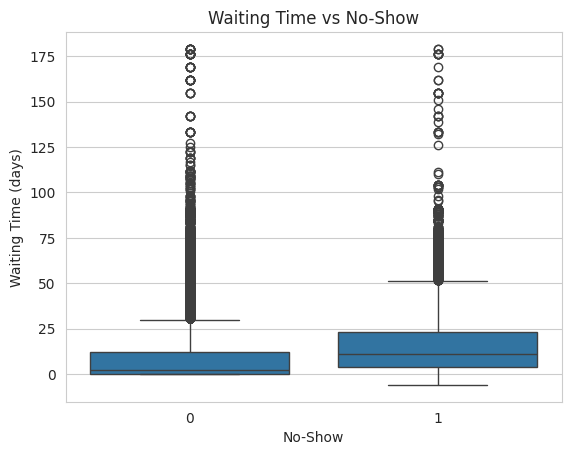

In [41]:
sns.boxplot(x='no-show', y='waiting_time', data=df)
plt.title("Waiting Time vs No-Show")
plt.xlabel("No-Show")
plt.ylabel("Waiting Time (days)")
plt.show()

# **SMS REMINDER IMPACT**

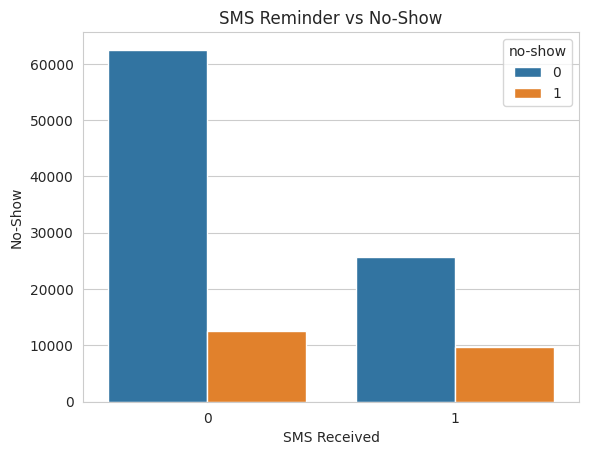

In [43]:
sns.countplot(x='sms_received', hue='no-show', data=df)
plt.title("SMS Reminder vs No-Show")
plt.xlabel("SMS Received")
plt.ylabel("No-Show")
plt.show()

# **HEALTH CONDITION ANALYSIS**

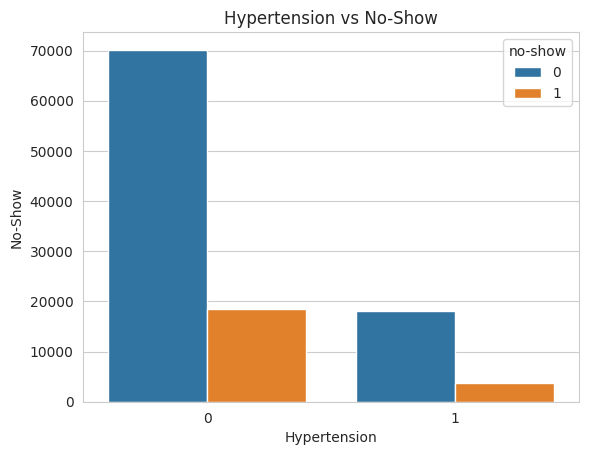

In [45]:
sns.countplot(x='hipertension', hue='no-show', data=df)
plt.title("Hypertension vs No-Show")
plt.xlabel("Hypertension")
plt.ylabel("No-Show")
plt.show()

# **DAY OF WEEK ANALYSIS**

In [47]:
df['appointment_day'] = ps.to_datetime(df['appointmentday'])
df['day_of_week'] = df['appointment_day'].dt.day_name()
df['day_of_week'].head()

,day_of_week
0,Friday
1,Friday
2,Friday
3,Friday
4,Friday


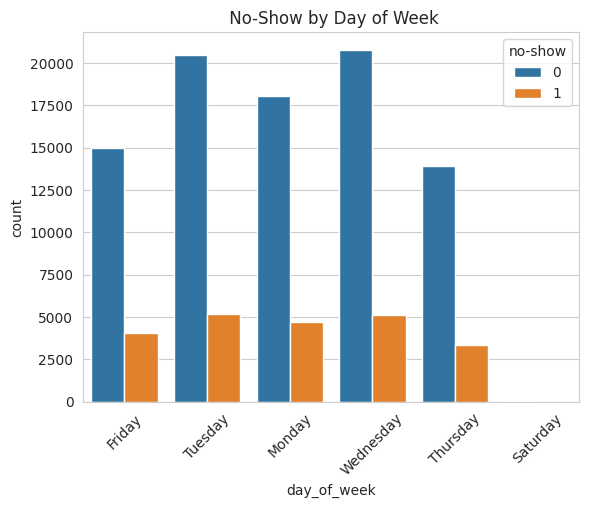

In [49]:
sns.countplot(x='day_of_week',hue='no-show',data=df)
plt.title(" No-Show by Day of Week")
plt.xticks(rotation = 45)
plt.show()

# **TOP NEIGHBORHOODS WITH NO-SHOWS**

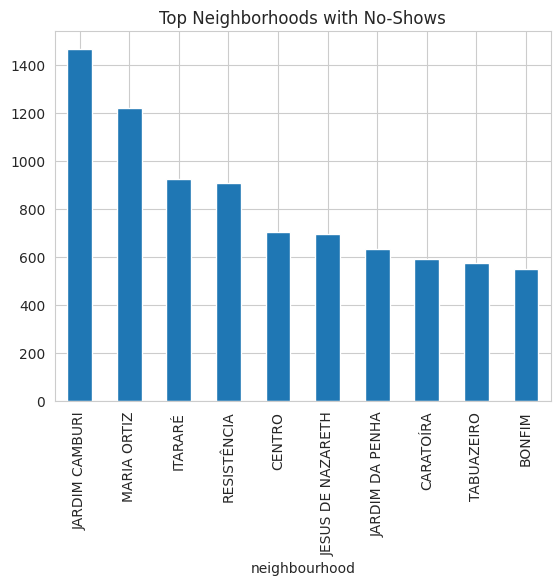

In [51]:
top_neigh = df[df['no-show']==1]["neighbourhood"].value_counts().head(10)
top_neigh.plot(kind='bar')
plt.title("Top Neighborhoods with No-Shows")
plt.show()

# **CORRELATION HEATMAP**

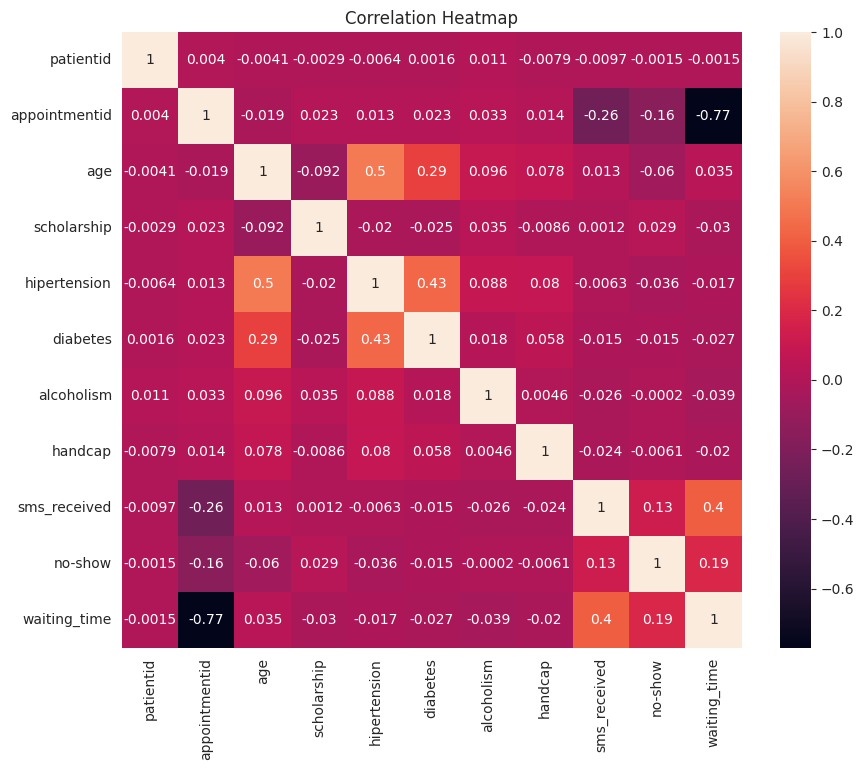

In [52]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

# **SAVE FIGURES**

In [53]:
plt.savefig("plot_name.png")

<Figure size 640x480 with 0 Axes>

# **FINAL VERIFICATION**

In [54]:
df.info()
df.head()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   patientid        110526 non-null  int64         
 1   appointmentid    110526 non-null  int64         
 2   gender           110526 non-null  object        
 3   scheduledday     110526 non-null  object        
 4   appointmentday   110526 non-null  object        
 5   age              110526 non-null  int64         
 6   neighbourhood    110526 non-null  object        
 7   scholarship      110526 non-null  int64         
 8   hipertension     110526 non-null  int64         
 9   diabetes         110526 non-null  int64         
 10  alcoholism       110526 non-null  int64         
 11  handcap          110526 non-null  int64         
 12  sms_received     110526 non-null  int64         
 13  no-show          110526 non-null  int64         
 14  scheduled_day    110526 n

,0
patientid,0
appointmentid,0
gender,0
scheduledday,0
appointmentday,0
age,0
neighbourhood,0
scholarship,0
hipertension,0
diabetes,0


# **INSIGHTS**

The analysis reveals that patient no - shows are influenced by multiple factors including age , waiting time and health conditions . Younger individuals and those with longer scheduling gaps are more likely to miss appointments  , while patients with chronic illnesses show higher attendance . additionally , SMS reminders alone are not sufficient to ensure atendance , indicating the need for more effective engagement strategies .

# **CONCLUSION**

The dataset was successfully cleaned and standardized by :


*   Handling missing values .
*   Remove duplicate records .


*   Converting date formats .
*   Standardizing categorical text values .


*   Renaming columns for consistency .
*   Fixing incorrect data types .